In [598]:
import pandas as pd
import numpy as np
import math
from surprise import Dataset, Reader, SVD, accuracy
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import random
import matplotlib.pyplot as plt
import tf2onnx
import onnx
import onnxruntime as ort
import os

<!-- # Testdata, based on entity list provided by App4Sales -->

<!-- ## Customers -->

In [599]:
# Address

#   Guid Id
#   String City
#   String State
#   Guid CustomerGuid

In [600]:
# Customer

#   Int32 Index
#   String Name
#   String ContactFullName

In [601]:
# ## Example Address 
# {
#   "id": "3f1c2a9e-7b4c-4e8d-9b21-6a0f9e4c1234",
#   "city": "Amsterdam",
#   "state": "Noord-Holland",
#   "customerGuidCustomer": "8a7b6c5d-4e3f-42a1-9c88-123456789abc"
# }

In [602]:
# # example customer
# {
#   "index": 1,
#   "customerGuid": "8a7b6c5d-4e3f-42a1-9c88-123456789abc",
#   "klantCode": 60635,
#   "name": "Primary Contact",
#   "contactFullName": "Lucas Hoek"
# }

<!-- ## Items -->

In [603]:
# Item

# +Int32 Index
# +String Unit
# +Decimal LastAvailableStock
# +String SearchDescription
# +String ItemCode
# +Decimal SalesPrice
# +String CatalogDescription
# +String Description
# +Decimal MinimumOrderQuantity
# +Boolean IsDeleted


In [604]:
# {
#   "index": 1,
#   "unit": "pcs",
#   "lastAvailableStock": 125.50,
#   "searchDescription": "Wireless ergonomic keyboard",
#   "itemCode": "KB-WL-ERG-001",
#   "salesPrice": 79.99,
#   "catalogDescription": "Ergonomic Wireless Keyboard",
#   "description": "A comfortable, wireless ergonomic keyboard suitable for daily office use.",
#   "minimumOrderQuantity": 1,
#   "isDeleted": False
# }

In [605]:
# {
#   "index": 2,
#   "unit": "pcs",
#   "lastAvailableStock": 125.50,
#   "searchDescription": "Wired ergonomic keyboard",
#   "ItemCode": "KB-WL-ERG-003",
#   "salesPrice": 79.99,
#   "catalogDescription": "Ergonomic Wired Keyboard",
#   "description": "A comfortable, wired ergonomic keyboard suitable for daily office use.",
#   "minimumOrderQuantity": 1,
#   "isDeleted": False
# }

In [606]:
# ItemClass

# +Int32 Id
# +String Description
# +String ItemCode

In [607]:

# {
#   "itemClassId": 10,
#   "description": "Electronics Accessories",
#   "itemCode": "KB-WL-ERG-001"
# }


In [608]:
# ItemClassValue

# +Int32 ItemClassId
# +String Description
# +Int32 Sequence

In [609]:

# {
#   "itemClassId": 10,
#   "description": "Electronics Accessories",
#   "sequence": 1
# }


<!-- ## Order -->

In [610]:
# {
#     "orderId": 24862,
#     "customerName": "John Doe",
#     "klantcode": 60635,
#     "orderDate": "2024-06-15T14:30:00Z",
#     "orderType": "Standard",
#     "Created" : "2024-06-15T14:30:00Z",
# }

<!-- ### orderlist

een orderlist bevat productorders. Er is maar 1 orderlist per order maar er kunnnen meerdere productorders in 1 orderlist zitten. deze zijn verbonden door middel van het Id -->

In [611]:
# {
#     "orderId": 24862,
#     "ItemCode": "KB-WL-ERG-001",
#     "quantity": 2
# }

In [612]:
# {
#     "orderId": 24862,
#     "ItemCode": "KB-WL-ERG-003",
#     "quantity": 1
# }

In [613]:
    # ------------------------------------------------------------
    # ✅ 1. Test Data 
    # ------------------------------------------------------------
test_data = {
        "Customers": [
            {
                "customerGuid": "8a7b6c5d-4e3f-42a1-9c88-123456789abc",
                "klantCode": 60635,
                "name": "Primary Contact",
                "contactFullName": "Lucas Hoek",
                "addresses": [
                    {
                    "id": "3f1c2a9e-7b4c-4e8d-9b21-6a0f9e4c1234",
                    "city": "Amsterdam",
                    "state": "Noord-Holland"
                }
            ]
        }
        ],
        "Items": [
        {
            "itemCode": "KB-WL-ERG-001",
            "unit": "pcs",
            "lastAvailableStock": 125.50,
            "searchDescription": "Wireless ergonomic keyboard",
            "salesPrice": 79.99,
            "catalogDescription": "Ergonomic Wireless Keyboard",
            "description": "A comfortable, wireless ergonomic keyboard suitable for daily office use.",
            "minimumOrderQuantity": 1,
            "isDeleted": False,

            "itemClass": {
                "itemClassId": 10,
                "description": "Electronics Accessories"
            },

            "itemClassValues": [
            {
            "itemClassId": 10,
            "description": "Electronics Accessories",
            "sequence": 1
            }
            ]
        }
    ],
    "Orders": [
        {
            "orderId": 24862,
            "customerName": "John Doe",
            "klantcode": 60635,
            "orderDate": "2024-06-15T14:30:00Z",
            "orderType": "Standard",
            "created": "2024-06-15T14:30:00Z",

            "orderLines": [
            {
                "itemCode": "KB-WL-ERG-001",
                "quantity": 2
            },
            {
                "ItemCode": "KB-WL-ERG-003",
                "quantity": 1
            }
        ]
        }
    ]
}

In [614]:
import uuid
from datetime import datetime, timedelta

# ------------------------------------------------------------
# Dutch name + address pools
# ------------------------------------------------------------

DUTCH_FIRST_NAMES = [
    "Lucas", "Daan", "Sem", "Finn", "Liam", "Noah", "Milan", "Bram", "Thijs", "Jesse",
    "Emma", "Sophie", "Julia", "Tess", "Sara", "Eva", "Lotte", "Nora", "Liv", "Fleur"
]

DUTCH_LAST_NAMES = [
    "de Jong", "Jansen", "de Vries", "van den Berg", "van Dijk", "Bakker",
    "Visser", "Smit", "Meijer", "Mulder", "Hoekstra", "van Leeuwen"
]

DUTCH_CITIES = [
    ("Amsterdam", "Noord-Holland"),
    ("Rotterdam", "Zuid-Holland"),
    ("Utrecht", "Utrecht"),
    ("Eindhoven", "Noord-Brabant"),
    ("Groningen", "Groningen"),
    ("Haarlem", "Noord-Holland"),
    ("Zwolle", "Overijssel"),
    ("Nijmegen", "Gelderland"),
    ("Tilburg", "Noord-Brabant"),
    ("Leiden", "Zuid-Holland")
]

PRODUCT_CATEGORIES = [
    "Office Supplies", "Electronics", "Lighting", "Furniture", "Tools",
    "Cables & Connectivity", "Storage", "Packaging", "Safety Equipment",
    "Cleaning Supplies", "Outdoor Equipment"
]

PRODUCT_NAMES = [
    "Wireless Mouse", "Ergonomic Keyboard", "LED Desk Lamp", "USB‑C Cable",
    "Office Chair", "Standing Desk", "Bluetooth Speaker", "Monitor Arm",
    "Laptop Stand", "Noise‑Cancelling Headset", "Barcode Scanner"
]

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def random_guid():
    return str(uuid.uuid4())

def random_dutch_name():
    return f"{random.choice(DUTCH_FIRST_NAMES)} {random.choice(DUTCH_LAST_NAMES)}"

def random_dutch_address():
    city, state = random.choice(DUTCH_CITIES)
    return {
        "id": random_guid(),
        "city": city,
        "state": state
    }

def random_item_code():
    return f"ITM-{uuid.uuid4().hex[:8].upper()}"

def random_price():
    return round(random.uniform(5.0, 499.0), 2)

def random_stock():
    return round(random.uniform(0, 500), 2)

def random_order_date():
    start = datetime(2023, 1, 1)
    end = datetime(2025, 12, 31)
    delta = end - start
    random_days = random.randint(0, delta.days)
    random_seconds = random.randint(0, 86400)
    return (start + timedelta(days=random_days, seconds=random_seconds)).isoformat() + "Z"

# ------------------------------------------------------------
# NEW GENERATOR
# ------------------------------------------------------------

def generate_realistic_app4sales_dataset(
    target_customers,
    target_items,
    target_categories,
    target_orders,
    seed=42
):
    random.seed(seed)
    np.random.seed(seed)

    dataset = {}

    # --------------------------------------------------------
    # 1. Generate Categories
    # --------------------------------------------------------
    categories = []
    class_values = []

    for i in range(target_categories):
        class_id = i + 1
        category_name = random.choice(PRODUCT_CATEGORIES) + f" {i+1}"

        categories.append({
            "itemClassId": class_id,
            "description": category_name
        })

        # 1–3 values per category
        for seq in range(random.randint(1, 3)):
            class_values.append({
                "itemClassId": class_id,
                "description": f"{category_name} Value {seq+1}",
                "sequence": seq + 1
            })

    # --------------------------------------------------------
    # 2. Generate Items
    # --------------------------------------------------------
    items = []

    for i in range(target_items):
        item_code = random_item_code()
        base_name = random.choice(PRODUCT_NAMES)
        class_obj = random.choice(categories)

        # Values for this class
        values = [v for v in class_values if v["itemClassId"] == class_obj["itemClassId"]]

        items.append({
            "itemCode": item_code,
            "unit": "pcs",
            "lastAvailableStock": random_stock(),
            "searchDescription": base_name,
            "salesPrice": random_price(),
            "catalogDescription": base_name,
            "description": f"{base_name} — high‑quality and suitable for professional use.",
            "minimumOrderQuantity": 1,
            "isDeleted": False,
            "itemClass": class_obj,
            "itemClassValues": values
        })

    # --------------------------------------------------------
    # 3. Generate Customers
    # --------------------------------------------------------
    customers = []

    for i in range(target_customers):
        guid = random_guid()
        klantcode = 60000 + i

        customers.append({
            "customerGuid": guid,
            "klantCode": klantcode,
            "name": random_dutch_name(),
            "contactFullName": random_dutch_name(),
            "addresses": [random_dutch_address()]
        })

    # --------------------------------------------------------
    # 4. Generate Orders (nested orderLines)
    # --------------------------------------------------------
    orders = []

    for i in range(target_orders):
        customer = random.choice(customers)
        num_lines = random.randint(1, 5)
        chosen_items = random.sample(items, num_lines)

        order_lines = []
        for it in chosen_items:
            order_lines.append({
                "itemCode": it["itemCode"],
                "quantity": random.randint(1, 10)
            })

        orders.append({
            "orderId": 20000 + i,
            "customerName": customer["name"],
            "klantcode": customer["klantCode"],
            "orderDate": random_order_date(),
            "orderType": random.choice(["Standard", "Express", "Backorder"]),
            "created": random_order_date(),
            "orderLines": order_lines
        })

    # --------------------------------------------------------
    # Final dataset
    # --------------------------------------------------------
    dataset["Customers"] = customers
    dataset["Items"] = items
    dataset["ItemClasses"] = categories
    dataset["ItemClassValues"] = class_values
    dataset["Orders"] = orders

    return dataset

# Example usage
dataset = generate_realistic_app4sales_dataset(
    target_customers=62538,
    target_items=7037,
    target_categories=129,
    target_orders=216608
)
# print(dataset)
print("Scaled dataset created:")
print(f"Customers: {len(dataset['Customers'])}")
print(f"Items: {len(dataset['Items'])}")
print(f"Categories: {len(dataset['ItemClasses'])}")
print(f"Category Values: {len(dataset['ItemClassValues'])}")
print(f"Orders: {len(dataset['Orders'])}")


Scaled dataset created:
Customers: 62538
Items: 7037
Categories: 129
Category Values: 262
Orders: 216608


<!-- # converting data to pandas dataframe -->

In [615]:
import pandas as pd

#items
items_base = pd.json_normalize(dataset["Items"])

# Item class values
items_values = pd.json_normalize(
    dataset["Items"],
    record_path="itemClassValues",
    meta=["itemCode"],
    record_prefix="classValue_",
)

# Merge them
items = items_base.merge(items_values, on="itemCode", how="left")

# Rename duplicate fields
items = items.rename(columns={
    "itemClass.description": "itemClass_description"
})

#customers
customers = pd.json_normalize(
    dataset["Customers"],
    record_path="addresses",
    meta=["customerGuid", "klantCode", "name", "contactFullName"],
    record_prefix="address_",
)

orders = pd.DataFrame(dataset["Orders"])
order_lines = pd.json_normalize(
    dataset["Orders"],
    record_path="orderLines",
    meta=["orderId", "customerName", "klantcode", "orderDate", "orderType", "created"],
    record_prefix="line_",
)

# Fix inconsistent casing
if "line_ItemCode" in order_lines.columns:
    order_lines["line_itemCode"] = order_lines["line_itemCode"].fillna(order_lines["line_ItemCode"])
    order_lines = order_lines.drop(columns=["line_ItemCode"])


print(items.head(), "\n")
print(customers.head(), "\n")
print(orders.head(), "\n")
print(order_lines.head(), "\n")


       itemCode unit  lastAvailableStock  searchDescription  salesPrice  \
0  ITM-FEE98FE7  pcs               48.47        USB‑C Cable      217.94   
1  ITM-FEE98FE7  pcs               48.47        USB‑C Cable      217.94   
2  ITM-FEE98FE7  pcs               48.47        USB‑C Cable      217.94   
3  ITM-2378F05F  pcs              233.51  Bluetooth Speaker      365.16   
4  ITM-2378F05F  pcs              233.51  Bluetooth Speaker      365.16   

  catalogDescription                                        description  \
0        USB‑C Cable  USB‑C Cable — high‑quality and suitable for pr...   
1        USB‑C Cable  USB‑C Cable — high‑quality and suitable for pr...   
2        USB‑C Cable  USB‑C Cable — high‑quality and suitable for pr...   
3  Bluetooth Speaker  Bluetooth Speaker — high‑quality and suitable ...   
4  Bluetooth Speaker  Bluetooth Speaker — high‑quality and suitable ...   

   minimumOrderQuantity  isDeleted  \
0                     1      False   
1                     

In [616]:
# ============================================================
# STEP 2 — BUILD MODELING DATASET
# ============================================================

# Merge order_lines with items (item features)
df = order_lines.merge(
    items,
    left_on="line_itemCode",
    right_on="itemCode",
    how="left"
)

# Merge with customers (customer features)
df = df.merge(
    customers,
    left_on="klantcode",
    right_on="klantCode",
    how="left"
)

# merged dataset = df
print(df.head())
print(df.shape)


  line_itemCode  line_quantity orderId customerName klantcode  \
0  ITM-F18095F7              9   20000   Sem Bakker     77703   
1  ITM-F18095F7              9   20000   Sem Bakker     77703   
2  ITM-F18095F7              9   20000   Sem Bakker     77703   
3  ITM-2229F498              2   20000   Sem Bakker     77703   
4  ITM-2229F498              2   20000   Sem Bakker     77703   

              orderDate  orderType               created      itemCode unit  \
0  2024-06-01T16:37:58Z  Backorder  2025-11-08T14:37:04Z  ITM-F18095F7  pcs   
1  2024-06-01T16:37:58Z  Backorder  2025-11-08T14:37:04Z  ITM-F18095F7  pcs   
2  2024-06-01T16:37:58Z  Backorder  2025-11-08T14:37:04Z  ITM-F18095F7  pcs   
3  2024-06-01T16:37:58Z  Backorder  2025-11-08T14:37:04Z  ITM-2229F498  pcs   
4  2024-06-01T16:37:58Z  Backorder  2025-11-08T14:37:04Z  ITM-2229F498  pcs   

   ...  classValue_itemClassId       classValue_description  \
0  ...                      26         Packaging 26 Value 1   
1  ...  

In [617]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ============================================================
# STEP 1 — CREATE POSITIVE INTERACTIONS
# ============================================================

interactions = df[['klantcode', 'itemCode']].drop_duplicates()
interactions['label'] = 1

# Encode users and items
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

interactions['user_id'] = user_encoder.fit_transform(interactions['klantcode'])
interactions['item_id'] = item_encoder.fit_transform(interactions['itemCode'])

num_users = interactions['user_id'].nunique()
num_items = interactions['item_id'].nunique()

# ============================================================
# STEP 2 — ADD user_id AND item_id BACK INTO df
# ============================================================

df = df.merge(
    interactions[['klantcode', 'user_id']].drop_duplicates(),
    on='klantcode',
    how='left'
)

df = df.merge(
    interactions[['itemCode', 'item_id']].drop_duplicates(),
    on='itemCode',
    how='left'
)

# ============================================================
# STEP 3 — NEGATIVE SAMPLING
# ============================================================

all_items = np.arange(num_items)
rng = np.random.default_rng(42)

neg_samples = []
user_group = interactions.groupby('user_id')['item_id'].apply(set)

for user, pos_items in user_group.items():
    n_pos = len(pos_items)
    candidates = rng.choice(all_items, size=n_pos * 3, replace=True)
    neg_items = [i for i in candidates if i not in pos_items][:n_pos]
    for item in neg_items:
        neg_samples.append((user, item, 0))

neg_df = pd.DataFrame(neg_samples, columns=['user_id', 'item_id', 'label'])

# Final dataset
interactions_all = pd.concat(
    [interactions[['user_id', 'item_id', 'label']], neg_df],
    ignore_index=True
)

train_df, val_df = train_test_split(
    interactions_all,
    test_size=0.2,
    random_state=42,
    stratify=interactions_all['label']
)

print(train_df.head())
print("Users:", num_users, "Items:", num_items)

# ============================================================
# STEP 4 — MERGE CUSTOMER + ITEM FEATURES
# ============================================================

# Customer features
cust_features = df[['klantcode', 'user_id', 'address_city', 'address_state']]
cust_features = cust_features.drop_duplicates('user_id')

# Item features
item_features = df[['itemCode', 'item_id', 'unit', 'classValue_itemClassId']]
item_features = item_features.drop_duplicates('item_id')

# Merge into training data
train_full = train_df.merge(cust_features, on='user_id', how='left')
train_full = train_full.merge(item_features, on='item_id', how='left')

val_full = val_df.merge(cust_features, on='user_id', how='left')
val_full = val_full.merge(item_features, on='item_id', how='left')

print(train_full.head())


         user_id  item_id  label
1155267    47426     5405      0
255816     59658     1091      1
1143513    46336     2598      0
158894     10432      415      1
598502      4424     4193      1
Users: 60553 Items: 7037
   user_id  item_id  label klantcode address_city  address_state  \
0    47426     5405      0    108999       Leiden   Zuid-Holland   
1    59658     1091      1    121619       Zwolle     Overijssel   
2    46336     2598      0    107883    Eindhoven  Noord-Brabant   
3    10432      415      1     70782    Rotterdam   Zuid-Holland   
4     4424     4193      1     64601    Amsterdam  Noord-Holland   

       itemCode unit  classValue_itemClassId  
0  ITM-C4995599  pcs                      88  
1  ITM-28DC0FF0  pcs                      44  
2  ITM-5FAB6D34  pcs                     125  
3  ITM-0F8A47A9  pcs                      72  
4  ITM-992844DC  pcs                     115  


In [618]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Inputs (main)
user_input = keras.Input(shape=(1,), name="user_id")
item_input = keras.Input(shape=(1,), name="item_id")
# reatures
city_input = keras.Input(shape=(1,), name="address_city")
state_input = keras.Input(shape=(1,), name="address_state")
unit_input = keras.Input(shape=(1,), name="unit")
class_input = keras.Input(shape=(1,), name="classValue_itemClassId")

# Embeddings
user_emb = layers.Embedding(num_users, 32)(user_input)
item_emb = layers.Embedding(num_items, 32)(item_input)
city_emb = layers.Embedding(train_full['address_city'].nunique(), 8)(city_input)
state_emb = layers.Embedding(train_full['address_state'].nunique(), 8)(state_input)
unit_emb = layers.Embedding(train_full['unit'].nunique(), 8)(unit_input)
class_emb = layers.Embedding(train_full['classValue_itemClassId'].nunique(), 8)(class_input)

# Flatten
u = layers.Flatten()(user_emb)
i = layers.Flatten()(item_emb)
c = layers.Flatten()(city_emb)
s = layers.Flatten()(state_emb)
u2 = layers.Flatten()(unit_emb)
cl = layers.Flatten()(class_emb)

# Combine all features
x = layers.Concatenate()([u, i, c, s, u2, cl])

# MLP
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)

output = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(
    inputs=[user_input, item_input, city_input, state_input, unit_input, class_input],
    outputs=output
)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["mse"])
model.summary()


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_id             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_id             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ address_city        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ address_state       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unit (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classValue_itemCla… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_108       │ (None, 1, 32)     │  1,937,696 │ user_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_109       │ (None, 1, 32)     │    225,184 │ item_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_110       │ (None, 1, 8)      │         80 │ address_city[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_111       │ (None, 1, 8)      │         56 │ address_state[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_112       │ (None, 1, 8)      │          8 │ unit[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_113       │ (None, 1, 8)      │      1,032 │ classValue_itemC… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_108         │ (None, 32)        │          0 │ embedding_108[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_109         │ (None, 32)        │          0 │ embedding_109[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_110         │ (None, 8)         │          0 │ embedding_110[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_111         │ (None, 8)         │          0 │ embedding_111[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_112         │ (None, 8)         │          0 │ embedding_112[0]… │
│ (Flatten)           │                   │            │                 

 Total params: 2,186,841 (8.34 MB)

 Trainable params: 2,186,841 (8.34 MB)

 Non-trainable params: 0 (0.00 B)

In [619]:
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# ============================================================
# ENCODE ALL CATEGORICAL FEATURES
# ============================================================

city_enc = LabelEncoder()
state_enc = LabelEncoder()
unit_enc = LabelEncoder()
class_enc = LabelEncoder()

train_full["address_city_enc"] = city_enc.fit_transform(train_full["address_city"].astype(str))
train_full["address_state_enc"] = state_enc.fit_transform(train_full["address_state"].astype(str))
train_full["unit_enc"] = unit_enc.fit_transform(train_full["unit"].astype(str))
train_full["class_enc"] = class_enc.fit_transform(train_full["classValue_itemClassId"].astype(str))

val_full["address_city_enc"] = city_enc.transform(val_full["address_city"].astype(str))
val_full["address_state_enc"] = state_enc.transform(val_full["address_state"].astype(str))
val_full["unit_enc"] = unit_enc.transform(val_full["unit"].astype(str))
val_full["class_enc"] = class_enc.transform(val_full["classValue_itemClassId"].astype(str))

# ============================================================
# BUILD TENSORFLOW DATASETS (NOW ALL INTEGERS)
# ============================================================

train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            "user_id": train_full["user_id"].values,
            "item_id": train_full["item_id"].values,
            "address_city": train_full["address_city_enc"].values,
            "address_state": train_full["address_state_enc"].values,
            "unit": train_full["unit_enc"].values,
            "classValue_itemClassId": train_full["class_enc"].values,
        },
        train_full["label"].values,
    )
).shuffle(200000).batch(2048)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            "user_id": val_full["user_id"].values,
            "item_id": val_full["item_id"].values,
            "address_city": val_full["address_city_enc"].values,
            "address_state": val_full["address_state_enc"].values,
            "unit": val_full["unit_enc"].values,
            "classValue_itemClassId": val_full["class_enc"].values,
        },
        val_full["label"].values,
    )
).batch(2048)

# ============================================================
# TRAIN
# ============================================================

model.fit(train_dataset, validation_data=val_dataset, epochs=5)


Epoch 1/5
507/507 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.6932 - mse: 0.2500 - val_loss: 0.6932 - val_mse: 0.2500
Epoch 2/5
507/507 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.6923 - mse: 0.2496 - val_loss: 0.6935 - val_mse: 0.2502
Epoch 3/5
507/507 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.6785 - mse: 0.2428 - val_loss: 0.7077 - val_mse: 0.2571
Epoch 4/5
507/507 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.6112 - mse: 0.2117 - val_loss: 0.7652 - val_mse: 0.2812
Epoch 5/5
507/507 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.4968 - mse: 0.1641 - val_loss: 0.8853 - val_mse: 0.3185


In [620]:
import tf2onnx
import tensorflow as tf

spec = (
    tf.TensorSpec((None, 1), tf.int32, name="user_id"),
    tf.TensorSpec((None, 1), tf.int32, name="item_id"),
    tf.TensorSpec((None, 1), tf.int32, name="address_city"),
    tf.TensorSpec((None, 1), tf.int32, name="address_state"),
    tf.TensorSpec((None, 1), tf.int32, name="unit"),
    tf.TensorSpec((None, 1), tf.int32, name="classValue_itemClassId"),
)

onnx_path = "ncf_model.onnx"

onnx_model, _ = tf2onnx.convert.from_keras(
    model,
    input_signature=spec,
    opset=17,
    output_path=onnx_path
)

print("Saved:", onnx_path)


Saved: ncf_model.onnx


<!-- ### NCF model -->

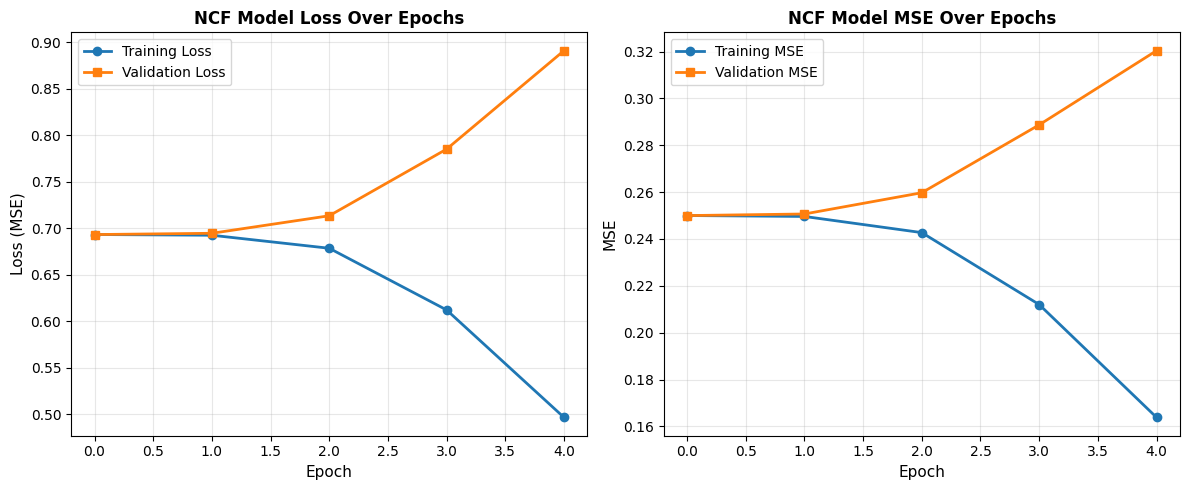


📊 Training Summary:
   Epochs completed: 5
   Final training loss: 0.496368
   Final validation loss: 0.891018
   Best validation loss: 0.693115


In [621]:

# Plot training history

if 'history_ncf' in locals():
    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history_ncf.history['loss'], label='Training Loss', linewidth=2, marker='o')
    plt.plot(history_ncf.history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
    plt.title('NCF Model Loss Over Epochs', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch', fontsize=11)
    plt.ylabel('Loss (MSE)', fontsize=11)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    # MSE plot
    plt.subplot(1, 2, 2)
    plt.plot(history_ncf.history['mse'], label='Training MSE', linewidth=2, marker='o')
    plt.plot(history_ncf.history['val_mse'], label='Validation MSE', linewidth=2, marker='s')
    plt.title('NCF Model MSE Over Epochs', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch', fontsize=11)
    plt.ylabel('MSE', fontsize=11)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Training Summary:")
    print(f"   Epochs completed: {len(history_ncf.history['loss'])}")
    print(f"   Final training loss: {history_ncf.history['loss'][-1]:.6f}")
    print(f"   Final validation loss: {history_ncf.history['val_loss'][-1]:.6f}")
    print(f"   Best validation loss: {min(history_ncf.history['val_loss']):.6f}")
else:
    print("ONNX model loaded, skipping training history plot.")

<!-- ### content based filtering, makes a Vectorized matrix of all text and then runs cosine between the product names, giving them a value of -1 and 1 using similarities between the items -->

In [622]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# Build item metadata text
# ------------------------------------------------------------

# 1. Extract item-level metadata from df

items_df = df[['itemCode', 'catalogDescription', 'classValue_description']].drop_duplicates('itemCode')

# 2. Build item metadata aligned with encoder
item_meta = pd.DataFrame({
    "item_id": np.arange(len(item_encoder.classes_)),
    "itemCode": item_encoder.classes_
})

# 3. Merge with item-level metadata
item_meta = item_meta.merge(
    items_df[['itemCode', 'catalogDescription', 'classValue_description']],
    on='itemCode',
    how='left'
)

item_meta['catalogDescription'] = item_meta['catalogDescription'].fillna("Unknown Item")
item_meta['classValue_description'] = item_meta['classValue_description'].fillna("No description")

# 4. Build text field
item_meta['text'] = item_meta['catalogDescription'] + " " + item_meta['classValue_description']



# ------------------------------------------------------------
# TF-IDF vectorization
# ------------------------------------------------------------
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(item_meta['text'])

# ------------------------------------------------------------
# Cosine similarity matrix
# ------------------------------------------------------------
content_sim = cosine_similarity(tfidf_matrix)

print(len(item_encoder.classes_))
print(item_meta['item_id'].nunique())
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Similarity matrix shape:", content_sim.shape)


7037
7037
TF-IDF matrix shape: (7037, 157)
Similarity matrix shape: (7037, 7037)


In [623]:
import os
import pickle
import joblib
from scipy import sparse

ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

def save_artifacts(
    artifacts_dir=ARTIFACTS_DIR,
    user_encoder=None,
    item_encoder=None,
    interactions_df=None,
    item_meta=None,
    tfidf=None,
    tfidf_matrix=None,
    onnx_model_path="ncf_model.onnx",
):
    os.makedirs(artifacts_dir, exist_ok=True)

    # Save encoders
    joblib.dump(user_encoder, os.path.join(artifacts_dir, "user_encoder.joblib"))
    joblib.dump(item_encoder, os.path.join(artifacts_dir, "item_encoder.joblib"))

    # Save dataframes
    joblib.dump(interactions_df, os.path.join(artifacts_dir, "interactions_df.joblib"))
    joblib.dump(item_meta, os.path.join(artifacts_dir, "item_meta.joblib"))

    # Save TF-IDF
    joblib.dump(tfidf, os.path.join(artifacts_dir, "tfidf_vectorizer.joblib"))
    sparse.save_npz(os.path.join(artifacts_dir, "tfidf_matrix.npz"), tfidf_matrix)

    # Save ONNX model path
    if os.path.exists(onnx_model_path):
        joblib.dump(onnx_model_path, os.path.join(artifacts_dir, "ncf_model_path.joblib"))

    print(f"Saved artifacts to {artifacts_dir}")


In [624]:
import onnxruntime as ort

def load_artifacts(artifacts_dir=ARTIFACTS_DIR, onnx_providers=None):
    if onnx_providers is None:
        onnx_providers = ["CPUExecutionProvider"]

    user_encoder = joblib.load(os.path.join(artifacts_dir, "user_encoder.joblib"))
    item_encoder = joblib.load(os.path.join(artifacts_dir, "item_encoder.joblib"))
    interactions_df = joblib.load(os.path.join(artifacts_dir, "interactions_df.joblib"))
    item_meta = joblib.load(os.path.join(artifacts_dir, "item_meta.joblib"))
    tfidf = joblib.load(os.path.join(artifacts_dir, "tfidf_vectorizer.joblib"))
    tfidf_matrix = sparse.load_npz(os.path.join(artifacts_dir, "tfidf_matrix.npz"))

    # Load ONNX model
    cf_model = None
    onnx_path_file = os.path.join(artifacts_dir, "ncf_model_path.joblib")
    if os.path.exists(onnx_path_file):
        onnx_path = joblib.load(onnx_path_file)
        if os.path.exists(onnx_path):
            cf_model = ort.InferenceSession(onnx_path, providers=onnx_providers)

    return {
        "user_encoder": user_encoder,
        "item_encoder": item_encoder,
        "interactions_df": interactions_df,
        "item_meta": item_meta,
        "tfidf": tfidf,
        "tfidf_matrix": tfidf_matrix,
        "cf_model": cf_model,
    }


In [625]:
import numpy as np

def cf_scores_for_user(user_idx, cf_session, item_indices):
    user_array = np.full((len(item_indices), 1), user_idx, dtype=np.int32)
    item_array = item_indices.reshape(-1, 1).astype(np.int32)

    # Fill missing feature inputs with zeros
    zeros = np.zeros_like(item_array)

    inputs = {
        "user_id": user_array,
        "item_id": item_array,
        "address_city": zeros,
        "address_state": zeros,
        "unit": zeros,
        "classValue_itemClassId": zeros,
    }

    preds = cf_session.run(None, inputs)[0].reshape(-1)
    return preds


In [626]:
def get_cf_topn(user_id, topn, artifacts, exclude_seen=True):
    user_encoder = artifacts["user_encoder"]
    item_encoder = artifacts["item_encoder"]
    interactions_df = artifacts["interactions_df"]
    cf_model = artifacts["cf_model"]

    if cf_model is None:
        raise RuntimeError("ONNX model not loaded.")

    if user_id not in user_encoder.classes_:
        return []

    user_idx = user_encoder.transform([user_id])[0]

    all_item_indices = np.arange(len(item_encoder.classes_))

    scores = cf_scores_for_user(user_idx, cf_model, all_item_indices)

    if exclude_seen:
        seen_items = interactions_df[interactions_df["user_id"] == user_idx]["item_id"].unique()
        for s in seen_items:
            scores[s] = -np.inf

    top_idx = np.argsort(-scores)[:topn]
    item_ids = item_encoder.inverse_transform(top_idx)

    return [(int(i), float(scores[int(i)])) for i in top_idx]

In [627]:
from sklearn.metrics.pairwise import linear_kernel

def get_content_topn_by_item(item_id, topn, artifacts):
    item_encoder = artifacts["item_encoder"]
    tfidf_matrix = artifacts["tfidf_matrix"]

    if item_id not in item_encoder.classes_:
        return []

    idx = item_encoder.transform([item_id])[0]

    sims = linear_kernel(tfidf_matrix[idx], tfidf_matrix).reshape(-1)
    sims[idx] = -np.inf

    top_idx = np.argsort(-sims)[:topn]
    item_ids = item_encoder.inverse_transform(top_idx)

    return list(zip(item_ids, sims[top_idx]))


In [628]:
def get_hybrid_topn(user_id, topn, artifacts, alpha=0.6):
    user_encoder = artifacts["user_encoder"]
    item_encoder = artifacts["item_encoder"]
    interactions_df = artifacts["interactions_df"]
    item_meta = artifacts["item_meta"]    
    tfidf_matrix = artifacts["tfidf_matrix"]
    cf_model = artifacts["cf_model"]

    # -----------------------------
    # 1. Validate user
    # -----------------------------
    if user_id not in user_encoder.classes_:
        return []

    # -----------------------------
    # 2. CF scores
    # -----------------------------
    cf = get_cf_topn(user_id, topn=500, artifacts=artifacts, exclude_seen=True)
    cf_dict = {i: s for i, s in cf}

    # -----------------------------
    # 3. Content-based scores
    # -----------------------------
    content_scores = {}
    for item_id, cf_score in cf:
        sims = get_content_topn_by_item(item_id, topn=20, artifacts=artifacts)
        for sim_item, sim_score in sims:
            content_scores[sim_item] = content_scores.get(sim_item, 0) + sim_score

    # -----------------------------
    # 4. Safe normalization
    # -----------------------------
    def norm(x):
        if not x:
            return {}
        arr = np.array(list(x.values()), dtype=np.float32)
        mn, mx = arr.min(), arr.max()
        if mx <= mn:
            return {k: 0.0 for k in x}
        return {k: (v - mn) / (mx - mn + 1e-9) for k, v in x.items()}

    cf_norm = norm(cf_dict)
    content_norm = norm(content_scores)

    # -----------------------------
    # 5. Hybrid score
    # -----------------------------
    hybrid = {}
    for item in set(cf_norm) | set(content_norm):
        hybrid[item] = alpha * cf_norm.get(item, 0) + (1 - alpha) * content_norm.get(item, 0)

    # -----------------------------
    # 6. Sort top-N
    # -----------------------------
    top_items = sorted(hybrid.items(), key=lambda x: -x[1])[:topn]

    # -----------------------------
    # 7. Enrich with item metadata
    # -----------------------------
    enriched = []
    for item_id, score in top_items:
        row = item_meta[item_meta["item_id"] == item_id]

        if row.empty:
            continue

        row = row.iloc[0]

        enriched.append({
            "item_id": item_id,
            "item_code": row["itemCode"],
            "item_name": row["catalogDescription"],
            "item_description": row["classValue_description"],
            "score": float(score)
        })

    return enriched


In [629]:
# ------------------------------------------------------------
# SAVE ARTIFACTS
# ------------------------------------------------------------

save_artifacts(
    artifacts_dir="artifacts",
    user_encoder=user_encoder,
    item_encoder=item_encoder,
    interactions_df=interactions_all,   # user_id, item_id, label
    item_meta=item_meta,                # item_id, name, classValue_description, text
    tfidf=tfidf,
    tfidf_matrix=tfidf_matrix,
    onnx_model_path="ncf_model.onnx"
)


Saved artifacts to artifacts


In [630]:
artifacts = load_artifacts("artifacts")
print("item_encoder size:", len(item_encoder.classes_))
print("item_meta size:", artifacts["item_meta"]["item_id"].nunique())

missing = set(range(len(item_encoder.classes_))) - set(artifacts["item_meta"]["item_id"])
print("Missing item_ids:", list(missing)[:20])
print("Total missing:", len(missing))


item_encoder size: 7037
item_meta size: 7037
Missing item_ids: []
Total missing: 0


In [631]:
customer_id = 60635

topn_hybrid = get_hybrid_topn(customer_id, topn=5, artifacts=artifacts)

for r in topn_hybrid:
    print(f"{r['item_description']} | {r['item_code']} | Score: {r['score']:.4f}")


Electronics 98 Value 1 | ITM-5AAE803D | Score: 0.6000
Cleaning Supplies 24 Value 1 | ITM-FB807E4D | Score: 0.5799
Safety Equipment 88 Value 1 | ITM-E907A2A0 | Score: 0.5727
Cleaning Supplies 24 Value 1 | ITM-6B7C2EB6 | Score: 0.5480
Packaging 128 Value 1 | ITM-FFA34F3F | Score: 0.5465
